# 4b)
## 2. Noisy Data

In [175]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math
from torch.utils.data import Dataset, DataLoader, random_split

In [176]:
device = "cuda" if torch.cuda.is_available() else "cpu"

Code from Part 1 4a)

In [177]:
# Summary Network
class SummaryNet(nn.Module):
    def __init__(self, phi: nn.Module, out_dim = 64):
        '''Remove the last layer of the input network phi and use it as summary network'''
        super().__init__()
        self.backbone = nn.Sequential(*list(phi.net.children())[:-1]) # remove last layer of phi(x)
        last_linear = None
        for m in reversed(list(self.backbone.children())):
            if isinstance(m, nn.Linear):
                last_linear = m
                break
        if last_linear is None:
            raise RuntimeError("No Linear layer found in backbone")
        
        self.proj = nn.Linear(last_linear.out_features, out_dim)

    def forward(self, x):
        z = self.backbone(x)
        z = self.proj(z)
        return z
    
##  conditional coupling flow from task 3 HW 3
def subnet_constructor(input_size, hidden_size, output_size):
    model = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size,hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, output_size)
    )
    return model

def orthogonal_matrix(dim):
    A = torch.normal(mean=torch.zeros(dim,dim), std=torch.ones(dim, dim))
    Q, _ = torch.linalg.qr(A)
    return Q


# conditional coupling block
class conditional_coupling_block(nn.Module):
    def __init__(self, input_size, hidden_size, condition_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.condition_size = condition_size

        self.split1 = self.input_size // 2
        self.split2 = self.input_size - self.split1

        self.subnet = subnet_constructor(self.split1+ self.condition_size, 
                                         self.hidden_size, 
                                         2 * self.split2) # output: s, t
    
    def forward(self, x, cond, rev=False):
        x1, x2 = x[..., :self.split1], x[..., self.split1: ]

        params = self.subnet(torch.cat([x1, cond], -1)) # get s, t from subnetwork
        s, t = params[..., :self.split2], params[..., self.split2: ]
        s = 0.8 *torch.tanh(s)
        ljd = torch.sum(s, -1)
        
        if not rev:
            x2 = torch.exp(s) * x2 + t # affine transformation on split 2
            return torch.cat([x1,x2], -1), ljd
        
        else:
            x2 = torch.exp(-s) * (x2 - t)
            return torch.cat([x1, x2], -1)

class conditional_realNVP(nn.Module):
    def __init__(self, input_size, hidden_size, n_blocks, condition_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.n_blocks = n_blocks
        self.condition_size = condition_size

        self.coupling_blocks = nn.ModuleList([
            conditional_coupling_block(input_size, hidden_size, condition_size) for _ in range(n_blocks)
        ])

        self.register_buffer(
            "orthogonal_matrices",
            torch.stack([orthogonal_matrix(input_size) for _ in range(n_blocks-1)], dim=0)
        )

    def forward(self, x, cond, rev=False):
        if rev:
            return self._inverse(x, cond)
        return self._forward(x, cond)
        
    def _forward(self, x, cond):
        ljd = torch.zeros((x.shape[0]))
        for l in range(self.n_blocks-1):
            x, partial_ljd = self.coupling_blocks[l](x, cond)
            ljd += partial_ljd
            x = torch.matmul(x, self.orthogonal_matrices[l])
        x, partial_ljd = self.coupling_blocks[-1](x, cond)
        ljd += partial_ljd
        return x, ljd
    
    def _inverse(self, x, cond):
       
        for l in range(self.n_blocks-1, 0, -1):
            x = self.coupling_blocks[l](x, cond, rev=True)
            x = torch.matmul(x, self.orthogonal_matrices[l-1].T)
        x = self.coupling_blocks[0](x, cond, rev=True)
        return x
    
    def log_prob(self, y, cond):
        z, ljd = self.forward(y, cond, rev=False)
        log_base = -0.5 * (z**2).sum(dim=-1) - 0.5 * self.input_size * math.log(2*math.pi)
        return log_base + ljd
    
    def sample(self, num_samples, cond):
        if cond.dim() == 1:
            cond = cond.unsqueeze(0) # (1, cond_dim)
        B = cond.shape[0]
        z = torch.randn(B * num_samples, self.input_size) # z ~ N(0,I)
        cond_rep = cond.repeat_interleave(num_samples, dim=0) # (c[0], c[0]..., c[1],....)
        y = self._inverse(z, cond_rep) # y = f^-1(z;c)
        return y

In [178]:
def simulate_sir_simple(lam, mu, I_0, T=100, N=1000):
    '''
    arg:
    N total population
    --- parameters not directely known ---
    lam infection rate
    mu recovery rate
    I_0 initial number of infected
    --------------------------------------
    T number of days

    returns:
    x sequence of observations [(Delta S(1), Delta R(1)), ... ]
    c sequence of ODE variables [(S(1), I(1), R(1)), .... ]
    '''
    # initial conditions
    S = N - I_0
    I = I_0
    R = 0

    S_list = [S]
    I_list = [I]
    R_list = [R]

    # simulate day-by-day
    for t in range(T):
        # dynamics
        dS = -lam * S * I / N
        dI = lam * S * I / N - mu * I
        dR = mu * I

        # update
        S += dS
        I += dI
        R += dR

        # store
        S_list.append(S)
        I_list.append(I)
        R_list.append(R)

    # Convert to numpy for easier ops
    S_arr = np.array(S_list)
    I_arr = np.array(I_list)
    R_arr = np.array(R_list)

    # Observations: ΔS(t), ΔR(t), t=1..T
    dS = S_arr[:-1] - S_arr[1:]
    dR = R_arr[1:] - R_arr[:-1]

    x = np.stack([dS, dR], axis=1)
    c = np.stack([S_arr[1:], I_arr[1:], R_arr[1:]], axis=1)
    return x, c


In [179]:
#Regression Network
class MLPRegressor(nn.Module):
    """
    y = Phi(x)
    """
    def __init__(self, in_dim=200, hidden=(256, 256), out_dim=6):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            d = h
        layers += [nn.Linear(d, out_dim)] # last layer
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

New code starting here:

In [180]:
def simulate_sir_noisy(lam, mu, I_0, L, rho, sigma_2, T):
    
    X, c = simulate_sir_simple(lam, mu, I_0, T=T)
    dS = X[:,0]
    dR = X[:,1]
    
    dS_delayed = np.zeros_like(dS)
    dR_delayed = np.zeros_like(dR)
    
    if L == 0:
        dS_delayed = dS
        dR_delayed = dR
    elif L<T:
        dS_delayed[L:] = dS[:-L]
        dR_delayed[L:] = dR[:-L]
    
    sigma = np.sqrt(sigma_2)
    
    eps_S = []
    eps_R = []
    
    for x in range(T):
        e_s = -1.0
        while e_s<=0:
            e_s = np.random.normal(rho, sigma)
        eps_S.append(e_s)
        e_r = -1.0
        while e_r<=0:
            e_r = np.random.normal(rho, sigma)
        eps_R.append(e_r)
    
    eps_S = np.array(eps_S)
    eps_R = np.array(eps_R)
    
    dS_noisy = dS_delayed * eps_S
    dR_noisy = dR_delayed * eps_R
    
    X_tilde = np.stack([dS_noisy, dR_noisy], axis=1)
    
    return X_tilde, c
    

In [181]:
def train_posterior(summary_net, flow, loader, device="cpu", epochs=30, lr=1e-3):
    summary_net.to(device)
    flow.to(device)

    opt = torch.optim.Adam(list(summary_net.parameters()) + list(flow.parameters()), lr=lr)

    for ep in range(1, epochs+1):
        summary_net.train()
        flow.train()
        total = 0.0 

        for X, Y in loader:
            X, Y = X.to(device), Y.to(device)
            cond = summary_net(X)
            logp = flow.log_prob(Y, cond)
            loss = (-logp).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

            total += loss.item() * X.size(0)
        print(f"epoch {ep:3d} | NLL {total / len(loader.dataset):.4f}")
        
def train(phi, loader, epochs = 30):
    opt = torch.optim.Adam(phi.parameters(), 1e-3)
    for i in range(epochs):
        for X,Y in loader:
            loss = ((phi(X.to(device)) - Y.to(device)) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
            

In [182]:
def resimulate_from_posterior(flow, summary, x, T = 100, n = 500):
    flow.eval()
    summary.eval()
    with torch.no_grad():
        cond = summary(x.unsqueeze(0))
        samples = flow.sample(n, cond).cpu().numpy()
    
    trajectory = []
    for lam, mu, logI0, L, rho, log_sigma_2 in samples:
        new_L = int(np.clip(round(L), 0, T-1))
        x_sim, s = simulate_sir_noisy(lam, mu, np.exp(logI0), L=new_L, rho = rho, sigma_2 = np.exp(log_sigma_2), T=T)
        trajectory.append(x_sim[:,0])
    return np.array(trajectory)

In [183]:
def prior_noisy_sample(n):
    
    lam = np.random.uniform(0.4, 0.5, n)
    mu  = np.random.uniform(0.05, 0.1625, n)
    I0  = np.random.uniform(5, 20, n)
    L   = np.random.randint(0, 11, n)         
    rho = np.random.uniform(0.6, 1.0, n)    
    sigma_2 = np.random.uniform(0.01, 0.2, n)
    
    return np.stack([lam, mu, np.log(I0),L,rho, np.log(sigma_2)], axis=1)

In [184]:
#replace SIRDataset with noisy observations
class SIRNoisyDataset(Dataset):
    def __init__(self, n, T=100, N=10000):
        Y = prior_noisy_sample(n)
        X = []
        for lam, mu, I0, L, rho, sigma_2 in Y:
            x, _ = simulate_sir_noisy(lam, mu, np.exp(I0), L = int(L), rho = rho, sigma_2 = np.exp(sigma_2), T = T)
            x = x / N
            X.append(x.reshape(-1))
            
        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.Y = torch.tensor(np.array(Y), dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [185]:
# Training

noisy_dataset = SIRNoisyDataset(20000, T = 100, N=10000)
noisy_train, noisy_val = random_split(noisy_dataset, [16000, 4000])

train_loader = DataLoader(noisy_train, batch_size=256, shuffle=True)
val_loader   = DataLoader(noisy_val, batch_size=256)

phi = MLPRegressor(out_dim = 6)
train(phi, train_loader)
summary_net = SummaryNet(phi, out_dim=64)

flow = conditional_realNVP(
    input_size=6,
    hidden_size=128,
    n_blocks=6,
    condition_size=64
)

train_posterior(
    summary_net=summary_net,
    flow=flow,
    loader=train_loader,
    device=device,
    epochs=30,
    lr=1e-3
)

epoch   1 | NLL 5.4187
epoch   2 | NLL -0.7253
epoch   3 | NLL -1.8583
epoch   4 | NLL -2.3128
epoch   5 | NLL -2.4750
epoch   6 | NLL -2.7029
epoch   7 | NLL -2.5738
epoch   8 | NLL -2.8627
epoch   9 | NLL -2.8377
epoch  10 | NLL -3.1302
epoch  11 | NLL -2.7386
epoch  12 | NLL -3.1914
epoch  13 | NLL -3.2284
epoch  14 | NLL -3.1833
epoch  15 | NLL -3.4935
epoch  16 | NLL -3.5117
epoch  17 | NLL -3.3815
epoch  18 | NLL -3.5498
epoch  19 | NLL -3.6217
epoch  20 | NLL -3.8005
epoch  21 | NLL -3.8986
epoch  22 | NLL -3.9102
epoch  23 | NLL -3.6623
epoch  24 | NLL -4.0025
epoch  25 | NLL -3.9698
epoch  26 | NLL -3.8877
epoch  27 | NLL -3.8666
epoch  28 | NLL -4.1125
epoch  29 | NLL -4.0367
epoch  30 | NLL -4.2627


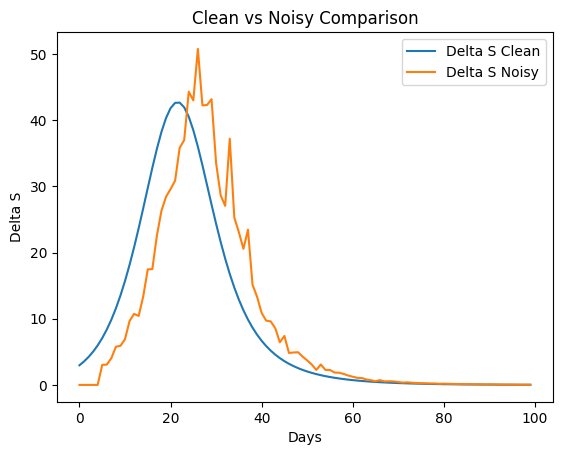

In [186]:
# Comparison Noisy vs. Clean

lam = 0.3
mu = 0.1
I0 = 10

x_clean, y_clean = simulate_sir_simple(lam, mu, I0)
x_noisy, y_noisy = simulate_sir_noisy(lam=lam, mu=mu, I_0=I0, L=5, rho=1.0, sigma_2=0.01, T = 100)

plt.plot(x_clean[:,0], label="Delta S Clean")
plt.plot(x_noisy[:,0], label="Delta S Noisy")
plt.legend()
plt.title("Clean vs Noisy Comparison")
plt.xlabel("Days")
plt.ylabel("Delta S")
plt.show()

The late start from the noisy data shows the effect of the reporting delay, L. The noisy data fluctuates alot compared to the clean data. The peak is also higher and has shifted to the right.

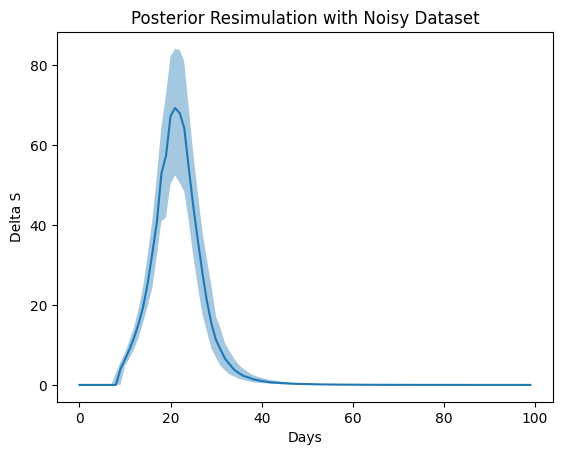

In [187]:
#Posterior Resimulation

x,y = next(iter(val_loader))
trajectory = resimulate_from_posterior(flow, summary_net, x[0], T=100, n=500)

plt.fill_between(range(100), np.percentile(trajectory, 25, axis=0), np.percentile(trajectory, 75, axis=0), alpha=0.4)

plt.plot(np.percentile(trajectory, 50, axis=0))
plt.title("Posterior Resimulation with Noisy Dataset")
plt.xlabel("Days")
plt.ylabel("Delta S")
plt.show()

The data starts at 0 and stays there for a few days which shows the effect of the reporting delay, L.

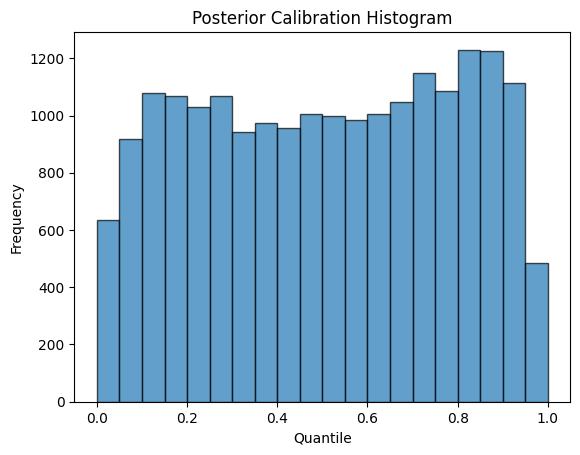

In [188]:
#Calibration Check

arr= []
flow.eval()
summary_net.eval()
with torch.no_grad():
    for X, Y in val_loader:
        X = X.to(device)
        Y = Y.numpy()
        for i in range(X.shape[0]):
            cod = summary_net(X[i].unsqueeze(0))
            smpls = flow.sample(1000, cod).cpu().numpy()
            for j in range(5):
                arr.append((smpls[:,j] < Y[i,j]).mean())
plt.hist(arr, bins = 20, alpha = 0.7, edgecolor='black')
plt.title("Posterior Calibration Histogram")
plt.xlabel("Quantile")
plt.ylabel("Frequency")
plt.show()

In [189]:
# Point Estimation
def loss(params):
    lam, mu, I0 = params
    x_sim, y_sim = simulate_sir_simple(lam, mu, I0)
    return np.sum((y_sim-y_noisy) ** 2)

from scipy.optimize import minimize
initial_guess = [0.2, 0.1, 1]
result = minimize(loss, initial_guess, bounds=[(0, 1), (0,1), (0,10)])
lam_est, mu_est, I0_est = result.x
print(f"Estimated parameters: \nlam: {lam_est}\nmu: {mu_est}\nI0 = {I0_est}")


Estimated parameters: 
lam: 0.29999997929544037
mu: 0.09999998194462575
I0 = 10.0


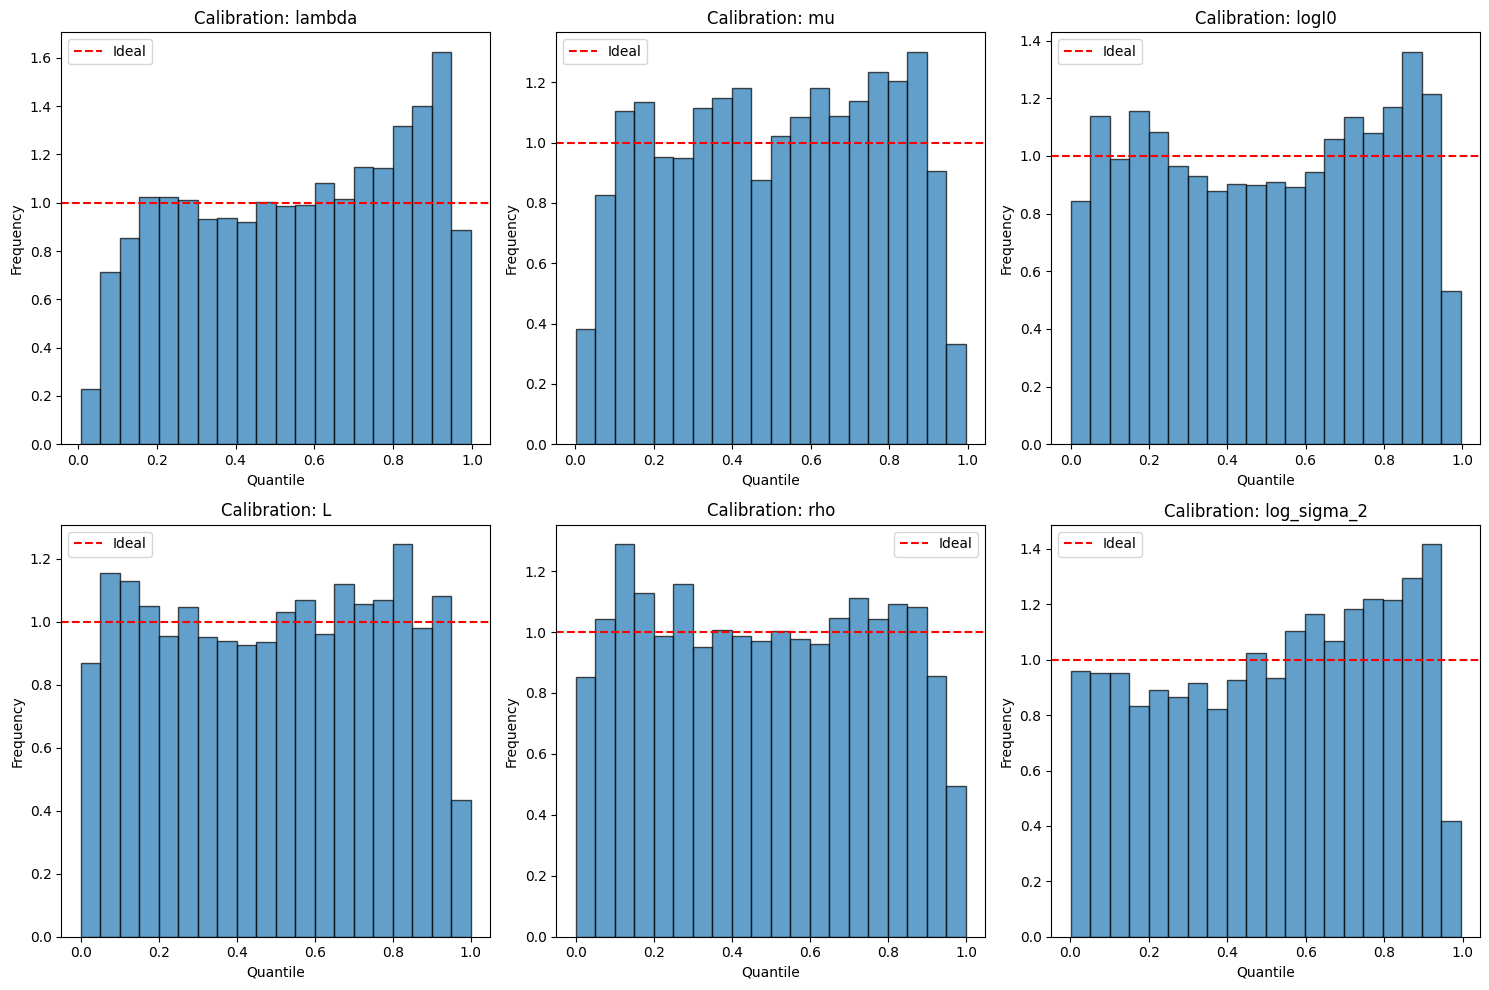

In [193]:
all_quantiles = [[] for i in range(6)]
flow.eval()
summary_net.eval()

with torch.no_grad():
    for X, Y in val_loader:
        X = X.to(device)
        Y = Y.cpu().numpy()

        cond = summary_net(X)
        for i in range(X.shape[0]):
            smpls = flow.sample(500, cond[i].unsqueeze(0)).cpu().numpy()
            for j in range(6):
                q = (smpls[:,j] < Y[i,j]).mean()
                all_quantiles[j].append(q)

fig, axes = plt.subplots(2,3, figsize = (15,10))
names = ['lambda', 'mu', 'logI0', 'L', 'rho', 'log_sigma_2']
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(all_quantiles[i], bins=20, density=True, alpha=0.7, edgecolor='black')
    ax.axhline(1.0, color='red', linestyle='--', label='Ideal')
    ax.set_title(f"Calibration: {names[i]}")
    ax.set_xlabel("Quantile")
    ax.set_ylabel("Frequency")
    ax.legend()
plt.tight_layout()
plt.show()


The histograms for $\lambda$ and $log(\sigma^2)$ have slightly higher slopes near the higher quantiles which shows that there could be a bias with the model. The other histograms are quite close to the ideal line and are mostly well-calibrated.

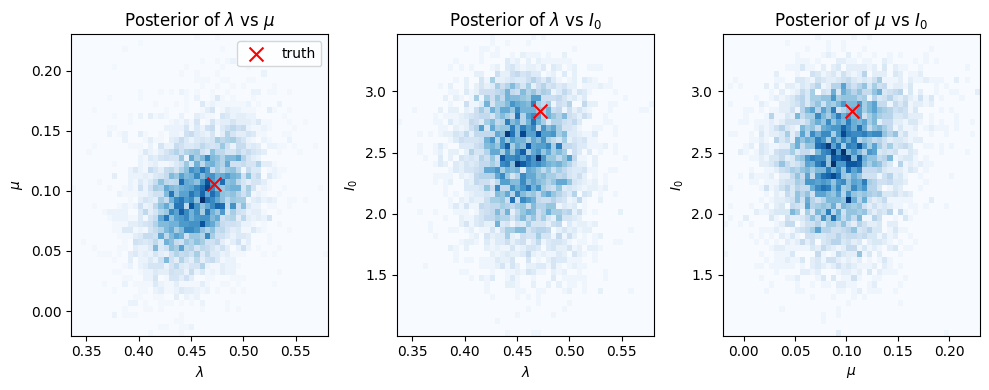

In [191]:
def plot_2d_posteriors_noisy(
    flow,
    summary_net,
    x,
    y_true,
    device="cpu",
    n_samples=5000,
):

    flow.eval()
    summary_net.eval()

    x = x.to(device).unsqueeze(0)

    with torch.no_grad():
        cond = summary_net(x)
        y_samples = flow.sample(n_samples, cond).cpu().numpy()

    y_true = np.asarray(y_true)
    pairs = [
        (0, 1, r"$\lambda$", r"$\mu$"),
        (0, 2, r"$\lambda$", r"$I_0$"),
        (1, 2, r"$\mu$", r"$I_0$"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    for ax, (i, j, xi, yj) in zip(axes, pairs):

        # posterior density
        ax.hist2d(y_samples[:, i], y_samples[:, j], bins=50, density=True, cmap="Blues")
        ax.scatter(y_true[i], y_true[j], color="red", s=100, marker="x", label="truth")
        ax.set_xlabel(xi)
        ax.set_ylabel(yj)
        ax.set_title(f"Posterior of {xi} vs {yj}")
    
    axes[0].legend()
    plt.tight_layout()
    plt.show()
    
X_val, Y_val = next(iter(val_loader))
plot_2d_posteriors_noisy(flow, summary_net, X_val[0], Y_val[0], device = device)


These plots show that the noisy data makes it harder to pin point the true value in comparison to the clean data.